# Etapa 1 - Buscador de imagenes por similitud

Notebook de trabajo de la Etapa 1: extraccion de embeddings con un
modelo pre-entrenado en ImageNet, construccion de la base vectorial,
busqueda por similitud y prediccion de raza por vecinos.

Requisitos previos (en el fork):
- `extract_embedding`, `search_similar_images` y
  `predict_breed_from_neighbors` implementadas en
  `src/lib/services/similarity_service.py` (esta notebook solo las
  orquesta).

Backend de base vectorial utilizado en esta notebook: JSON
(`EmbeddingStore`), por no contar con un servidor PostgreSQL en Colab.
La variante con pgvector se valida en el entorno local/Docker antes de
la entrega final.

## Equipo
- Agustín Accurso 
- Lautaro Cena

## 1. Clonar el repositorio

Como este notebook corre tanto en Google Colab (clonando el repo y
descargando el dataset) como en un entorno local ya clonado (donde
esos pasos ya estan hechos). La variable `IN_COLAB` controla que
celdas se ejecutan.

In [2]:
import sys

IN_COLAB = "google.colab" in sys.modules
print(f"Entorno Colab: {IN_COLAB}")

Entorno Colab: False


In [3]:
if IN_COLAB:
    REPO_URL = "https://github.com/accursoagus/tuia-dog-recognition-app.git"
    !git clone $REPO_URL proyecto
    %cd proyecto
else:
    print("Entorno local")

Entorno local


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv y numpy; solo se instala
lo que falta.

In [4]:
!pip install -q pydantic-settings python-dotenv kagglehub


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
if IN_COLAB:
    !pip install -q pydantic-settings python-dotenv kagglehub
else:
    print("Entorno local: dependencias ya instaladas via requirements.txt en el .venv.")

Entorno local: dependencias ya instaladas via requirements.txt en el .venv.


## 3. Configuracion del entorno

Se utiliza la base vectorial en formato JSON, ya que Colab no provee
PostgreSQL por defecto. La configuracion se define por variables de
entorno antes de importar `lib`.

In [6]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "true"

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data\dataset
GPU disponible: False


## 4. Descargar el dataset  

In [7]:
import subprocess
from pathlib import Path

if IN_COLAB or not (settings.dataset_path / "train").is_dir():
    subprocess.run([sys.executable, "scripts/download_dataset.py"], check=True)
else:
    print("Entorno local: dataset ya presente, se omite la descarga.")

print(sorted(p.name for p in settings.dataset_path.iterdir()))

Entorno local: dataset ya presente, se omite la descarga.
['.gitkeep', 'dogs.csv', 'test', 'train', 'valid']


## 5. Analisis del dataset

Distribucion de clases del conjunto de entrenamiento: cantidad de
imagenes por raza, sobre las 70 razas del dataset.

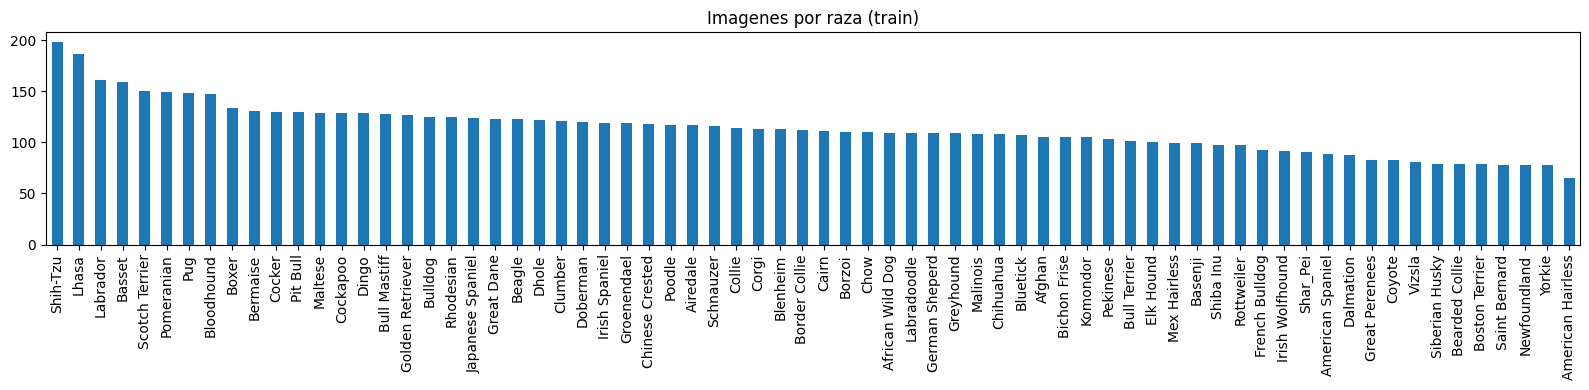

Total razas: 70
Min/Max imagenes por raza: 65 / 198


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

breeds = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
counts = {b: len(list((settings.dataset_path / "train" / b).glob("*.jpg"))) for b in breeds}

df_counts = pd.Series(counts).sort_values(ascending=False)
df_counts.plot(kind="bar", figsize=(16, 4), title="Imagenes por raza (train)")
plt.tight_layout()
plt.show()

print(f"Total razas: {len(breeds)}")
print(f"Min/Max imagenes por raza: {df_counts.min()} / {df_counts.max()}")

In [9]:
import cv2

print(f"Promedio de imagenes por raza: {df_counts.mean():.1f}")
print(f"Desvio estandar: {df_counts.std():.1f}")
print(f"Razas con menos de 100 imagenes: {(df_counts < 100).sum()} de {len(df_counts)}")

# Resolucion de las imagenes: confirmar si son realmente 224x224 como anuncia
# la pagina de Kaggle, o si varia (afecta la decision de resize).
sample_imgs = [cv2.imread(str(p)) for p in list((settings.dataset_path / "train" / breeds[0]).glob("*.jpg"))[:5]]
shapes = {img.shape for img in sample_imgs if img is not None}
print(f"Resoluciones encontradas (muestra): {shapes}")

Promedio de imagenes por raza: 113.5
Desvio estandar: 24.7
Razas con menos de 100 imagenes: 19 de 70
Resoluciones encontradas (muestra): {(224, 224, 3)}


**Conclusiones del analisis exploratorio:**

El dataset presenta 70 razas con un promedio de 113.5 imagenes por
raza (desvio estandar 24.7) y un rango de 65 a 198. El desbalance es
moderado: 19 de las 70 razas (27%) tienen menos de 100 imagenes, sin
llegar a casos extremos de escasez severa. Las imagenes verifican una
resolucion uniforme de 224x224x3, consistente con lo documentado por
el proveedor del dataset, por lo que el resize aplicado en el
preprocesamiento es principalmente una garantia de consistencia y no
una transformacion drastica sobre el contenido original.

Este desbalance no afecta a la Etapa 1 (el modelo de embeddings es
pre-entrenado y no se ajusta sobre este dataset), pero sí es relevante
para el fine-tuning de la Etapa 2.

### Splits provistos por el dataset

El dataset 70 Dog Breeds Image Dataset viene particionado de fabrica
en `train` (7946 imagenes), `valid` (700) y `test` (700), con las
mismas 70 razas en cada split.

In [10]:
for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split
    n_images = sum(1 for _ in split_path.rglob("*.jpg"))
    n_breeds = sum(1 for p in split_path.iterdir() if p.is_dir())
    print(f"{split}: {n_images} imagenes, {n_breeds} razas")

train: 7946 imagenes, 70 razas
valid: 700 imagenes, 70 razas
test: 700 imagenes, 70 razas


### Conjunto independiente de evaluacion

Conjunto adicional, fuera del dataset de Kaggle, con imagenes
descargadas manualmente de internet para algunas razas. Se utiliza
para evaluar la generalizacion del sistema fuera de la distribucion
de entrenamiento.

In [11]:
EXTERNAL_SET_PATH = settings.dataset_path.parent / "external_eval"

if EXTERNAL_SET_PATH.is_dir():
    n_external = sum(1 for _ in EXTERNAL_SET_PATH.rglob("*.jpg"))
    n_external_breeds = sum(1 for p in EXTERNAL_SET_PATH.iterdir() if p.is_dir())
    print(f"Conjunto externo: {n_external} imagenes, {n_external_breeds} razas")
else:
    print(f"Falta crear {EXTERNAL_SET_PATH} con imagenes descargadas manualmente de internet.")

Falta crear data\external_eval con imagenes descargadas manualmente de internet.


### Nota sobre Data Augmentation y filtrado de calidad

El preprocesamiento de Data Augmentation (horizontal flip, rotacion,
blur, variaciones de brillo/contraste, ruido) no aplica en esta etapa:
el modelo de embeddings es pre-entrenado en ImageNet y no se entrena
ni se ajusta sobre el dataset de razas, por lo que el augmentation no
tiene efecto sobre la calidad de los embeddings extraidos. Esta
tecnica se documenta y aplica en `etapa2_colab.ipynb`, donde sí se
entrena un modelo sobre el dataset.

El filtrado de imagenes de baja calidad tampoco se aplica de forma
activa en esta etapa: el dataset de Kaggle utilizado ya viene curado
(resolucion uniforme 224x224x3, verificado en la seccion de EDA), por
lo que no se detectaron imagenes corruptas o de calidad visiblemente
deficiente en la muestra inspeccionada.

## 6. Implementacion de extract_embedding (modelo baseline)

Se utiliza ResNet18 pre-entrenado en ImageNet, sin la capa de
clasificacion final (`fc`), como extractor de embeddings baseline.
Justificacion: la dimension de salida (512) coincide con
EMBEDDING_DIM por defecto del proyecto, y es la misma arquitectura
utilizada para el fine-tuning de la Etapa 2, lo que permite comparar
ambos extractores bajo igualdad de condiciones.

La implementacion vive en `SimilarityService.extract_embedding`
(`src/lib/services/similarity_service.py`); esta notebook la ejercita
sobre una imagen de prueba.

In [13]:
from lib.bootstrap import build_store, build_similarity

store = build_store(settings)
similarity = build_similarity(settings, store)

# Prueba rapida sobre una imagen
import cv2
sample_path = next((settings.dataset_path / "train" / breeds[0]).glob("*.jpg"))
sample_image = cv2.imread(str(sample_path))
embedding = similarity.extract_embedding(sample_image)
print(f"Dimension del embedding: {len(embedding)}")

INFO:lib.bootstrap:Using PostgreSQL vector store


Dimension del embedding: 512


In [14]:
from lib.bootstrap import build_store, build_similarity

store = build_store(settings)
similarity = build_similarity(settings, store)

sample_breed = breeds[0]
sample_path = next((settings.dataset_path / "train" / sample_breed).glob("*.jpg"))

import cv2
sample_image = cv2.imread(str(sample_path))
embedding = similarity.extract_embedding(sample_image)

print(f"Raza de prueba: {sample_breed}")
print(f"Dimension del embedding: {len(embedding)}")
assert len(embedding) == settings.embedding_dim, "El embedding no coincide con EMBEDDING_DIM configurado"

INFO:lib.bootstrap:Using PostgreSQL vector store


Raza de prueba: Afghan
Dimension del embedding: 512


## 7. Construccion de la base vectorial

Se indexan las imagenes del split `train` con `scripts/build_index.py`,
que invoca `extract_embedding` para cada imagen y persiste el
resultado en la base vectorial configurada (JSON en esta notebook).

In [15]:
result = subprocess.run(
    [sys.executable, "scripts/build_index.py", "--split", "train"],
    capture_output=True,
    text=True,
)
print(result.stdout)
print(result.stderr)
result.check_returncode()

Afghan: 105 imagenes indexadas
African Wild Dog: 109 imagenes indexadas
Airedale: 117 imagenes indexadas
American Hairless: 65 imagenes indexadas
American Spaniel: 89 imagenes indexadas
Basenji: 99 imagenes indexadas
Basset: 159 imagenes indexadas
Beagle: 123 imagenes indexadas
Bearded Collie: 79 imagenes indexadas
Bermaise: 131 imagenes indexadas
Bichon Frise: 105 imagenes indexadas
Blenheim: 113 imagenes indexadas
Bloodhound: 147 imagenes indexadas
Bluetick: 107 imagenes indexadas
Border Collie: 112 imagenes indexadas
Borzoi: 110 imagenes indexadas
Boston Terrier: 79 imagenes indexadas
Boxer: 134 imagenes indexadas
Bull Mastiff: 128 imagenes indexadas
Bull Terrier: 101 imagenes indexadas
Bulldog: 125 imagenes indexadas
Cairn: 111 imagenes indexadas
Chihuahua: 108 imagenes indexadas
Chinese Crested: 118 imagenes indexadas
Chow: 110 imagenes indexadas
Clumber: 121 imagenes indexadas
Cockapoo: 129 imagenes indexadas
Cocker: 130 imagenes indexadas
Collie: 114 imagenes indexadas
Corgi: 11

## 8. Busqueda por similitud y prediccion de raza

`search_similar_images` y `predict_breed_from_neighbors` se ejercitan
aqui sobre una imagen de prueba del split `test`, distinta de las
indexadas en el paso anterior.

In [16]:
import json

query_breed = breeds[0]
query_path = next((settings.dataset_path / "test" / query_breed).glob("*.jpg"))

result_path = similarity.search(
    source_path=str(query_path),
    output_path=settings.output_path,
)

result = json.loads(Path(result_path).read_text(encoding="utf-8"))

print(f"Raza real: {query_breed}")
print(f"Raza predicha: {result['predicted_breed']} (score={result['score']})")
print(f"Vecinos recuperados: {len(result['neighbors'])}")
for n in result["neighbors"][:5]:
    print(f"  - {n['breed']} (score={n['score']})")

UndefinedFunction: operator does not exist: vector <=> double precision[]
LINE 4:                 ORDER BY embedding <=> $1
                                           ^
HINT:  No operator matches the given name and argument types. You might need to add explicit type casts.

## 9. Evaluacion: NDCG@10

Para cada imagen del conjunto de test se ejecuta la busqueda completa,
se recuperan los Top-10 vecinos y se calcula NDCG@10, usando como
relevancia binaria si la raza del vecino coincide con la raza real de
la imagen consultada.

In [17]:
import numpy as np

def dcg_at_k(relevances: list[int], k: int) -> float:
    relevances = relevances[:k]
    return sum(rel / np.log2(idx + 2) for idx, rel in enumerate(relevances))

def ndcg_at_k(relevances: list[int], k: int) -> float:
    dcg = dcg_at_k(relevances, k)
    ideal = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg / idcg if idcg > 0 else 0.0

ndcg_scores = []
sample_size_per_breed = 5  # limitar para que la evaluacion no tarde demasiado en CPU

for breed in breeds:
    test_images = list((settings.dataset_path / "test" / breed).glob("*.jpg"))[:sample_size_per_breed]
    for img_path in test_images:
        image = cv2.imread(str(img_path))
        embedding = similarity.extract_embedding(image)
        neighbors = similarity.search_similar_images(embedding, top_k=10)
        relevances = [1 if n.breed == breed else 0 for n in neighbors]
        ndcg_scores.append(ndcg_at_k(relevances, 10))

print(f"NDCG@10 promedio: {np.mean(ndcg_scores):.4f}")
print(f"Imagenes evaluadas: {len(ndcg_scores)}")

UndefinedFunction: operator does not exist: vector <=> double precision[]
LINE 4:                 ORDER BY embedding <=> $1
                                           ^
HINT:  No operator matches the given name and argument types. You might need to add explicit type casts.

**Justificacion del resultado obtenido:**

TO-DO (completar una vez ejecutada la celda anterior): comentar el
valor de NDCG@10 obtenido, contrastandolo con lo esperable de un
modelo baseline (sin fine-tuning) y mencionando que razas, si las hay,
muestran score sistematicamente bajo (posible indicio de razas
visualmente similares entre si, ej. distintos terriers).

## 10. Visualizacion de embeddings (PCA / t-SNE)

Proyeccion a 2 dimensiones de los embeddings indexados (split train),
coloreada por raza, para observar si el espacio de embeddings agrupa
visualmente razas similares entre si.

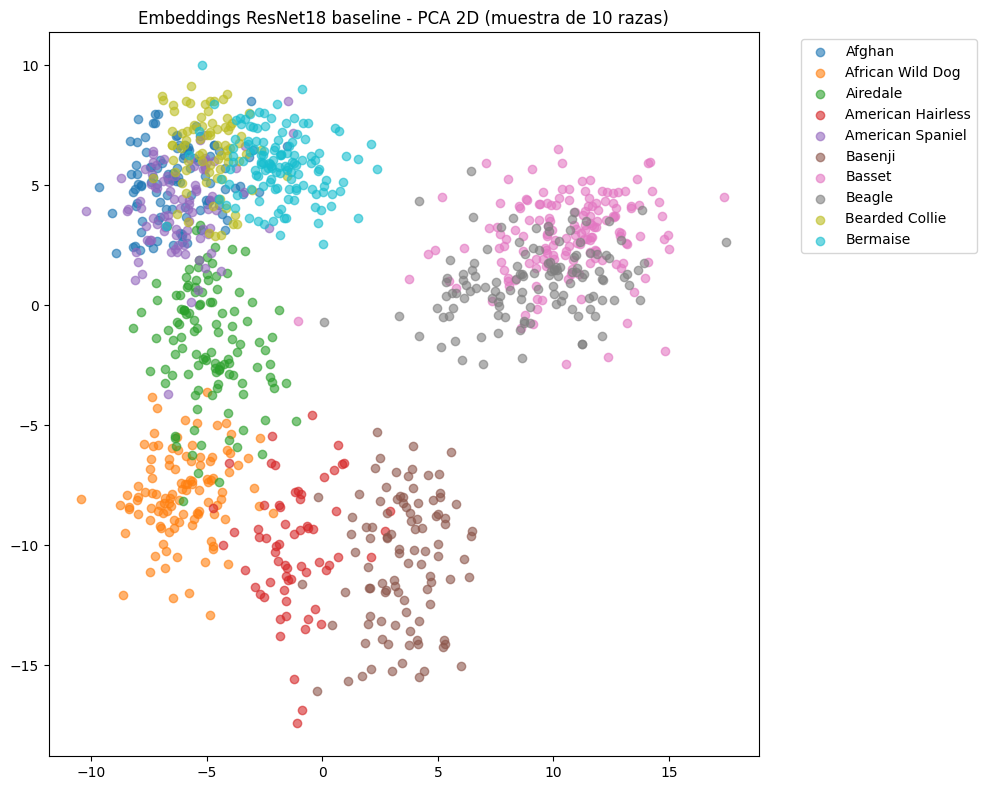

In [18]:
from sklearn.decomposition import PCA

all_records = store.all()
embeddings_matrix = np.array([r.embedding for r in all_records])
breed_labels = [r.breed for r in all_records]

# Se muestran solo 10 razas para que el grafico sea legible (70 colores
# distintos serian ilegibles en un solo scatter plot).
sample_breeds = breeds[:10]
mask = [b in sample_breeds for b in breed_labels]

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(embeddings_matrix[mask])

plt.figure(figsize=(10, 8))
for breed in sample_breeds:
    breed_mask = [b == breed for b in np.array(breed_labels)[mask]]
    plt.scatter(coords_2d[breed_mask, 0], coords_2d[breed_mask, 1], label=breed, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Embeddings ResNet18 baseline - PCA 2D (muestra de 10 razas)")
plt.tight_layout()
plt.show()

**Interpretacion del grafico:**

TO-DO (completar una vez ejecutada la celda anterior): comentar si las
razas se agrupan en clusters separables visualmente en el espacio 2D,
o si se superponen (lo cual seria esperable para razas con apariencia
fisica similar), y relacionar esa observacion con el resultado de
NDCG@10 de la seccion anterior.